In [2]:
from keras.applications.vgg16 import VGG16
model = VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


# 1. Initializing the VGG16 Model

First, we load the pre-trained VGG16 model from Keras applications. This model is a powerful convolutional neural network, pre-trained on the ImageNet dataset, and serves as our base for exploring internal representations.

In [3]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

# 2. Understanding the Model Architecture

To get an overview of the VGG16 model's structure, we display its summary, which lists all layers, their types, output shapes, and the number of parameters. This helps us understand the sequence of operations within the network.

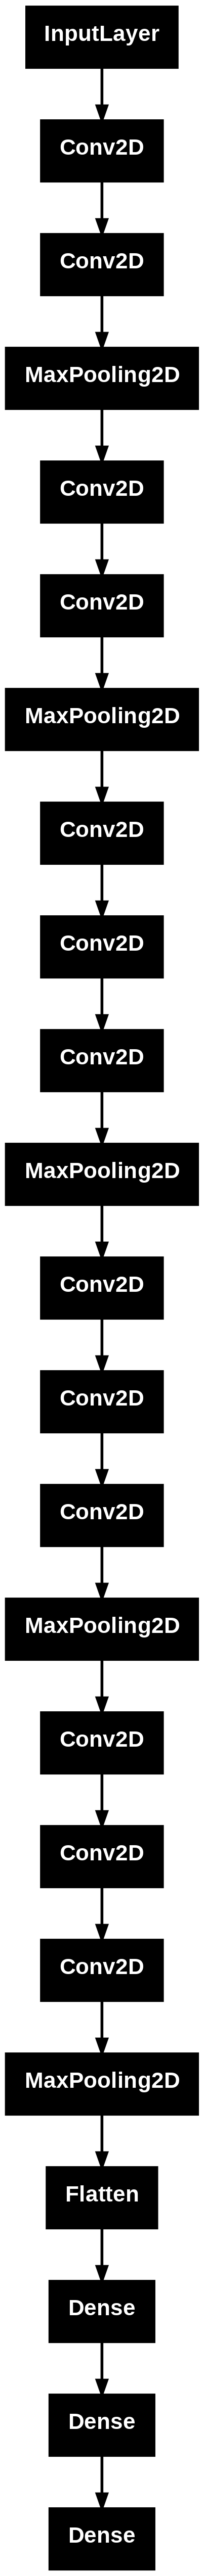

In [4]:
from keras.utils import plot_model

plot_model(model)

For a visual representation of the model's architecture, we can plot the model, showing the connections and flow of data between layers. This is especially useful for complex models like VGG16.

In [8]:
for i in range(len(model.layers)):
  if 'conv' not in model.layers[i].name:
    continue
  filter,biases = model.layers[i].get_weights()
  print("layer number",i,model.layers[i].name, filter.shape)

layer number 1 block1_conv1 (3, 3, 3, 64)
layer number 2 block1_conv2 (3, 3, 64, 64)
layer number 4 block2_conv1 (3, 3, 64, 128)
layer number 5 block2_conv2 (3, 3, 128, 128)
layer number 7 block3_conv1 (3, 3, 128, 256)
layer number 8 block3_conv2 (3, 3, 256, 256)
layer number 9 block3_conv3 (3, 3, 256, 256)
layer number 11 block4_conv1 (3, 3, 256, 512)
layer number 12 block4_conv2 (3, 3, 512, 512)
layer number 13 block4_conv3 (3, 3, 512, 512)
layer number 15 block5_conv1 (3, 3, 512, 512)
layer number 16 block5_conv2 (3, 3, 512, 512)
layer number 17 block5_conv3 (3, 3, 512, 512)


# 3. Inspecting Convolutional Filters

Convolutional layers are at the heart of feature extraction in CNNs. Here, we iterate through the model's layers to identify the convolutional layers and print the shape of their filters (weights). The filter shape tells us about the receptive field size (e.g., 3x3) and the number of input/output channels.

In [10]:
filters , bias = model.layers[1].get_weights()

Specifically, we extract the filters and biases from the first convolutional layer (`block1_conv1`, which is `model.layers[1]`). These filters are the actual patterns the network has learned to detect in the input image.

In [11]:
f_min , f_max = filters.min() , filters.max()
filters = (filters - f_min) / (f_max - f_min)

To make the filters visually interpretable, we normalize their values. This scales the pixel values of each filter to a range between 0 and 1, allowing them to be displayed as images.

**Exploring the filters**

In [38]:
import matplotlib.pyplot as pyplot

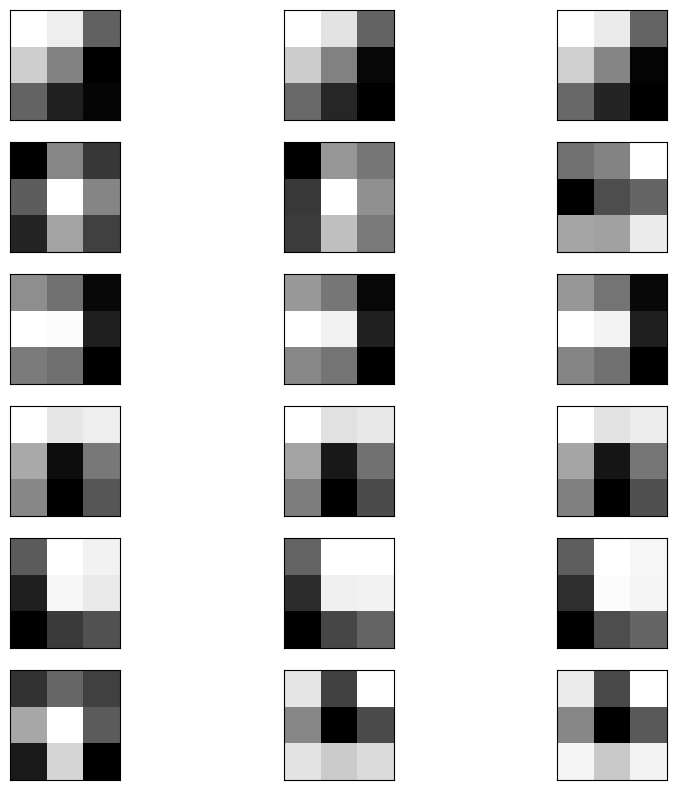

In [17]:
n_filters = 6
ix = 1
fig = pyplot.figure(figsize=(10,10))
for i in range(n_filters):
  f = filters[:,:,:,i]
  for j in range(3):
    ax = pyplot.subplot(n_filters, 3, ix)
    ax.set_xticks([])
    ax.set_yticks([])
    pyplot.imshow(f[:, :, j], cmap='gray')
    ix += 1
pyplot.show()

Here, we visualize the first few (six) filters of the first convolutional layer. Each filter is typically visualized across its input channels (e.g., RGB). These images show the basic features (like edges, textures, or color gradients) that this initial layer is looking for in an input image.

In [19]:
# submodel of VGG

from keras.models import Model

model = Model(inputs=model.inputs, outputs=model.layers[1].output)

# 4. Extracting Feature Maps from a Specific Layer

To observe how an image is transformed after passing through a particular layer, we create a new Keras `Model`. This sub-model takes the same input as the original VGG16 but outputs the activations (feature maps) of a chosen intermediate layer, in this case, the first convolutional layer (`model.layers[1]`).

In [42]:
from keras.utils import load_img, img_to_array
from keras.applications.vgg16 import preprocess_input
from numpy import expand_dims

image = load_img("/content/women.jpg",target_size=(224,224))



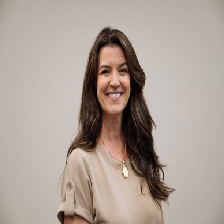

In [43]:
image

In [44]:
image = img_to_array(image)
image = expand_dims(image,axis=0)

image = preprocess_input(image)

We load an image, resize it to the VGG16's expected input dimensions (224x224 pixels), convert it to an array, add a batch dimension, and apply VGG16's specific preprocessing. This prepares the image for input to our sub-model.

In [45]:
features = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


Now, we use our sub-model to predict the feature maps for the preprocessed image. The output `features` represents the activations of the first convolutional layer when our image is passed through it. Each 'slice' of these features corresponds to the output of one filter.

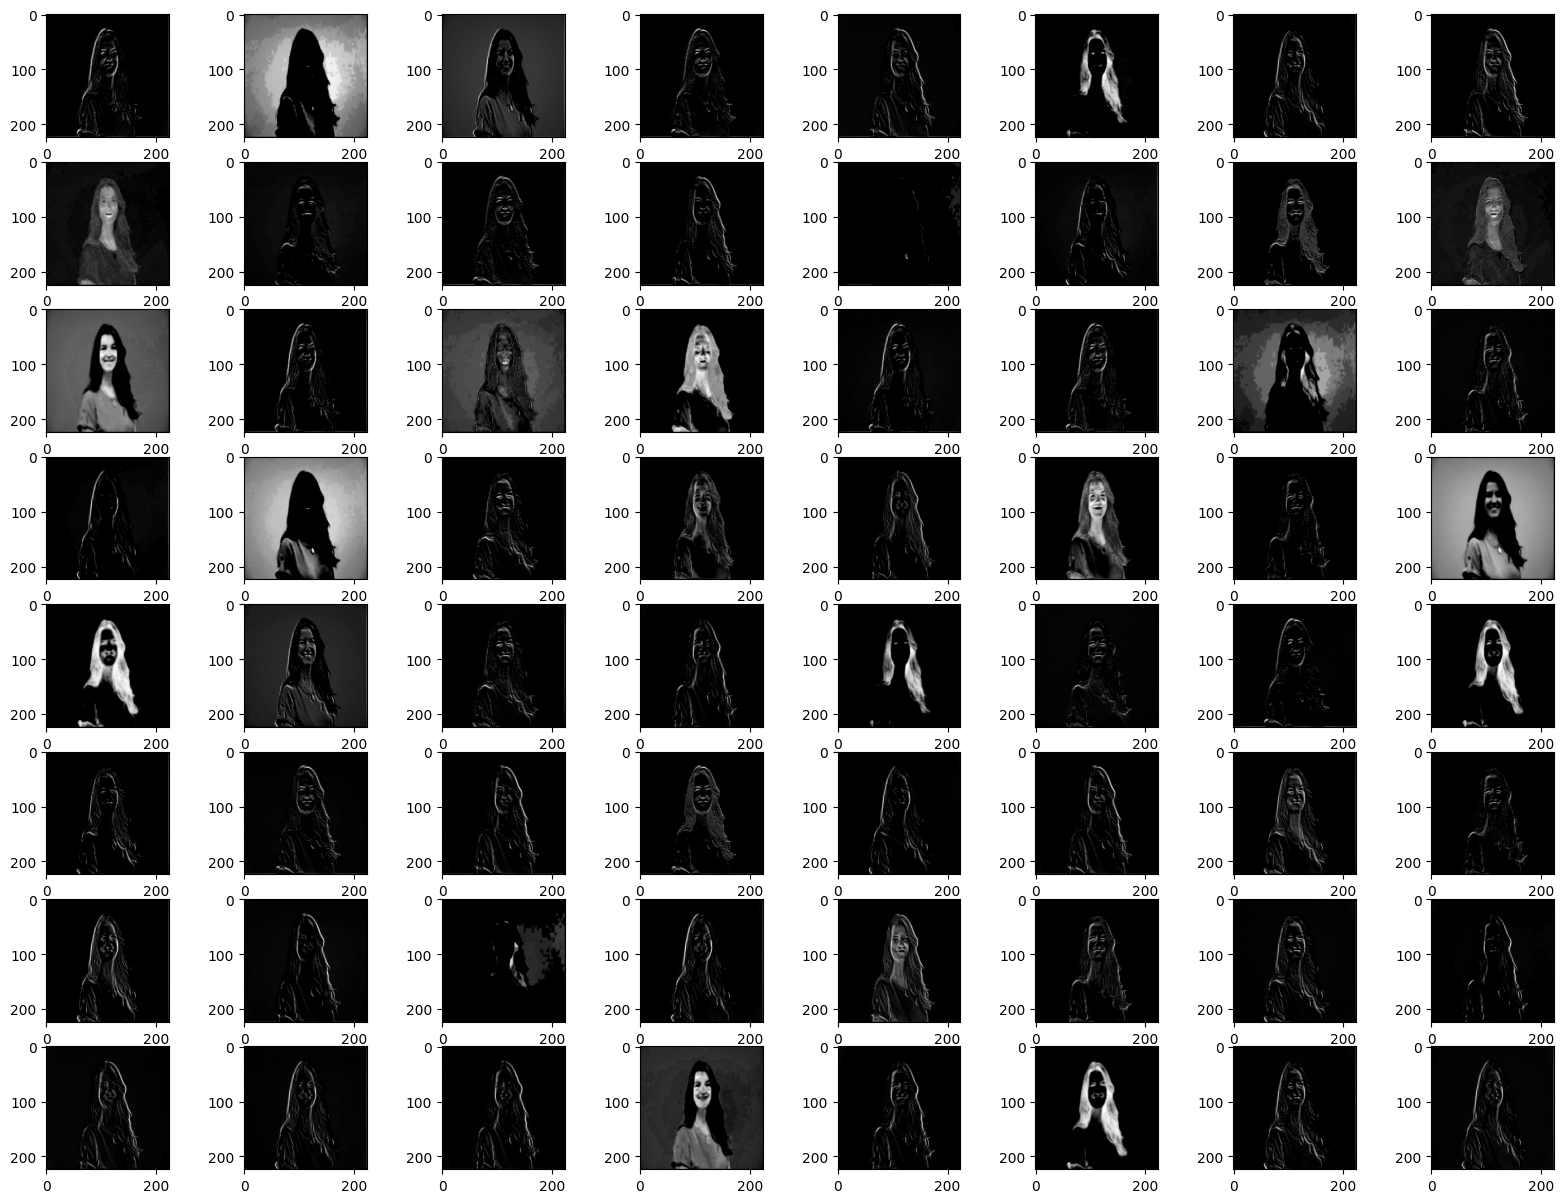

In [46]:
fig = pyplot.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):
  pyplot.subplot(8,8,i)

  pyplot.imshow(feature_maps[0,:,:,i-1],cmap='gray')

pyplot.show()

We visualize the feature maps generated by the first convolutional layer. Each subplot shows the output of a single filter, highlighting the patterns or regions in the input image that activated that specific filter. This gives us insight into what features the first layer is detecting.

we get 64 images as image passes through 64 filters of the first layer

In [48]:
model2 = VGG16()


In [49]:
layer_index = [2,5,9,13,17]
outputs = [model2.layers[i].output  for i in layer_index]
model3 = Model(inputs=model2.inputs, outputs=outputs)

# 5. Exploring Feature Maps from Multiple Intermediate Layers

To get a broader understanding of feature extraction across the network, we create another sub-model (`model3`). This time, it extracts feature maps from *multiple* selected convolutional layers (indices 2, 5, 9, 13, and 17). This allows us to observe how the features become more abstract and complex deeper into the network.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


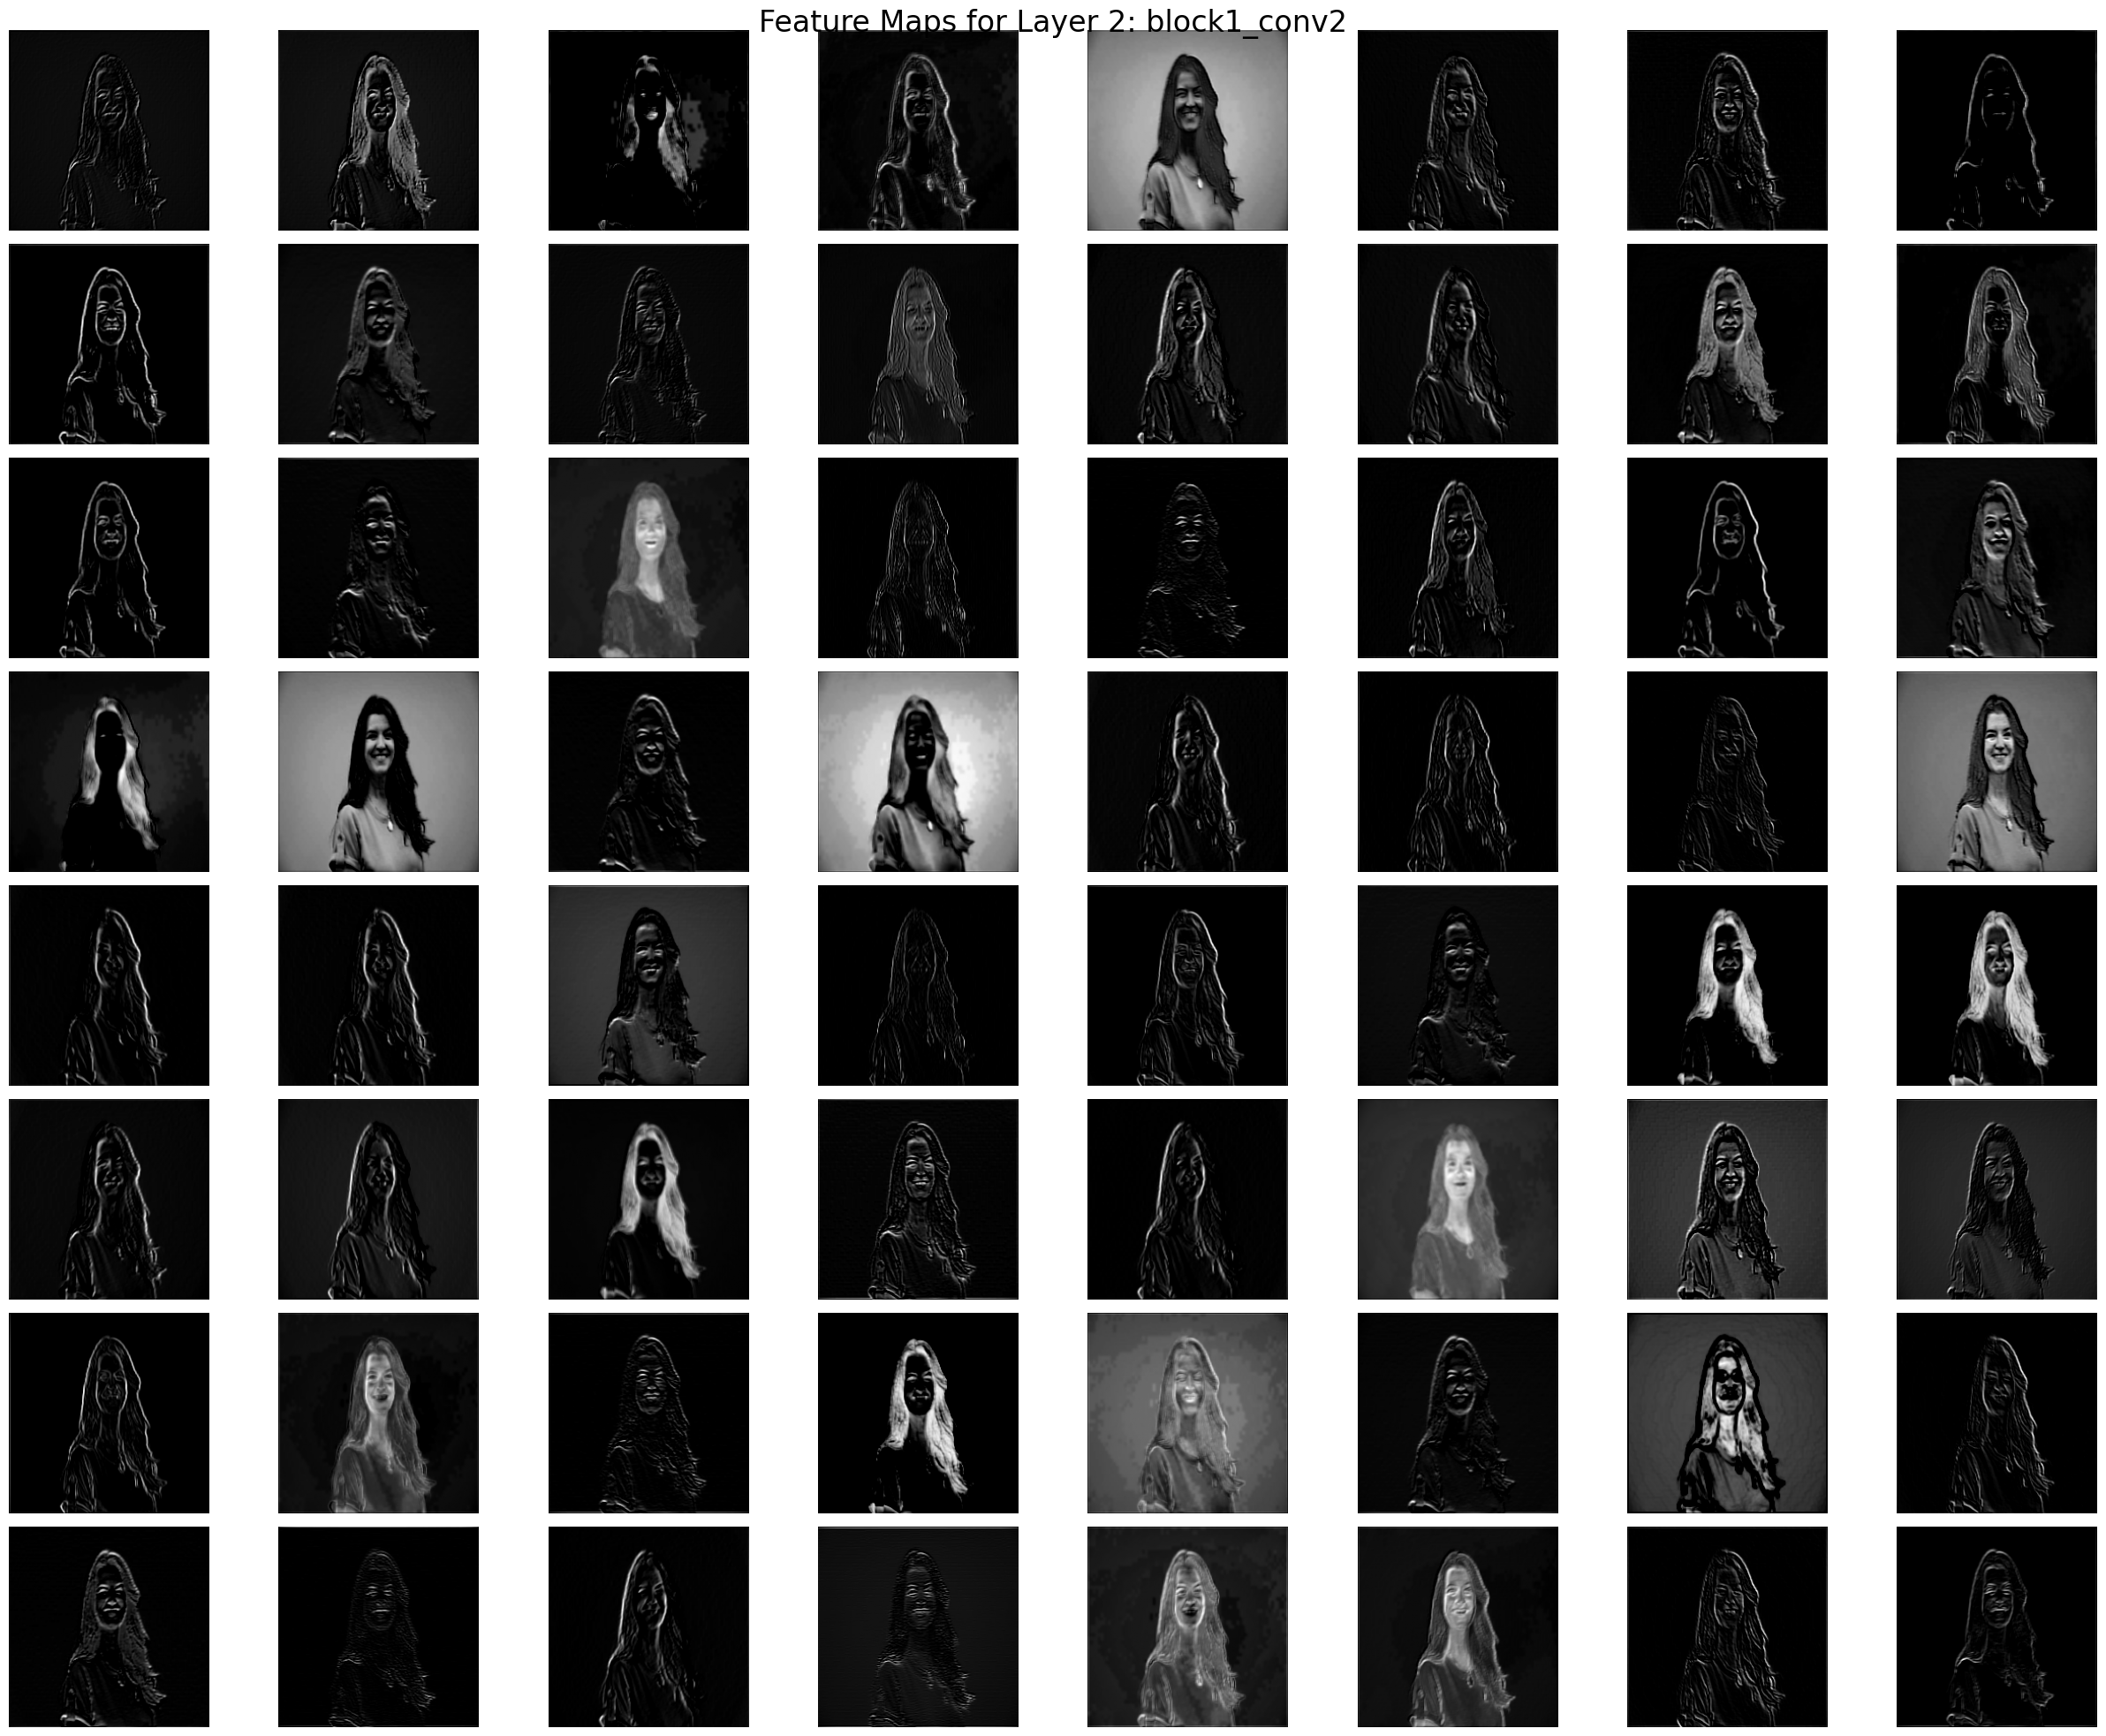

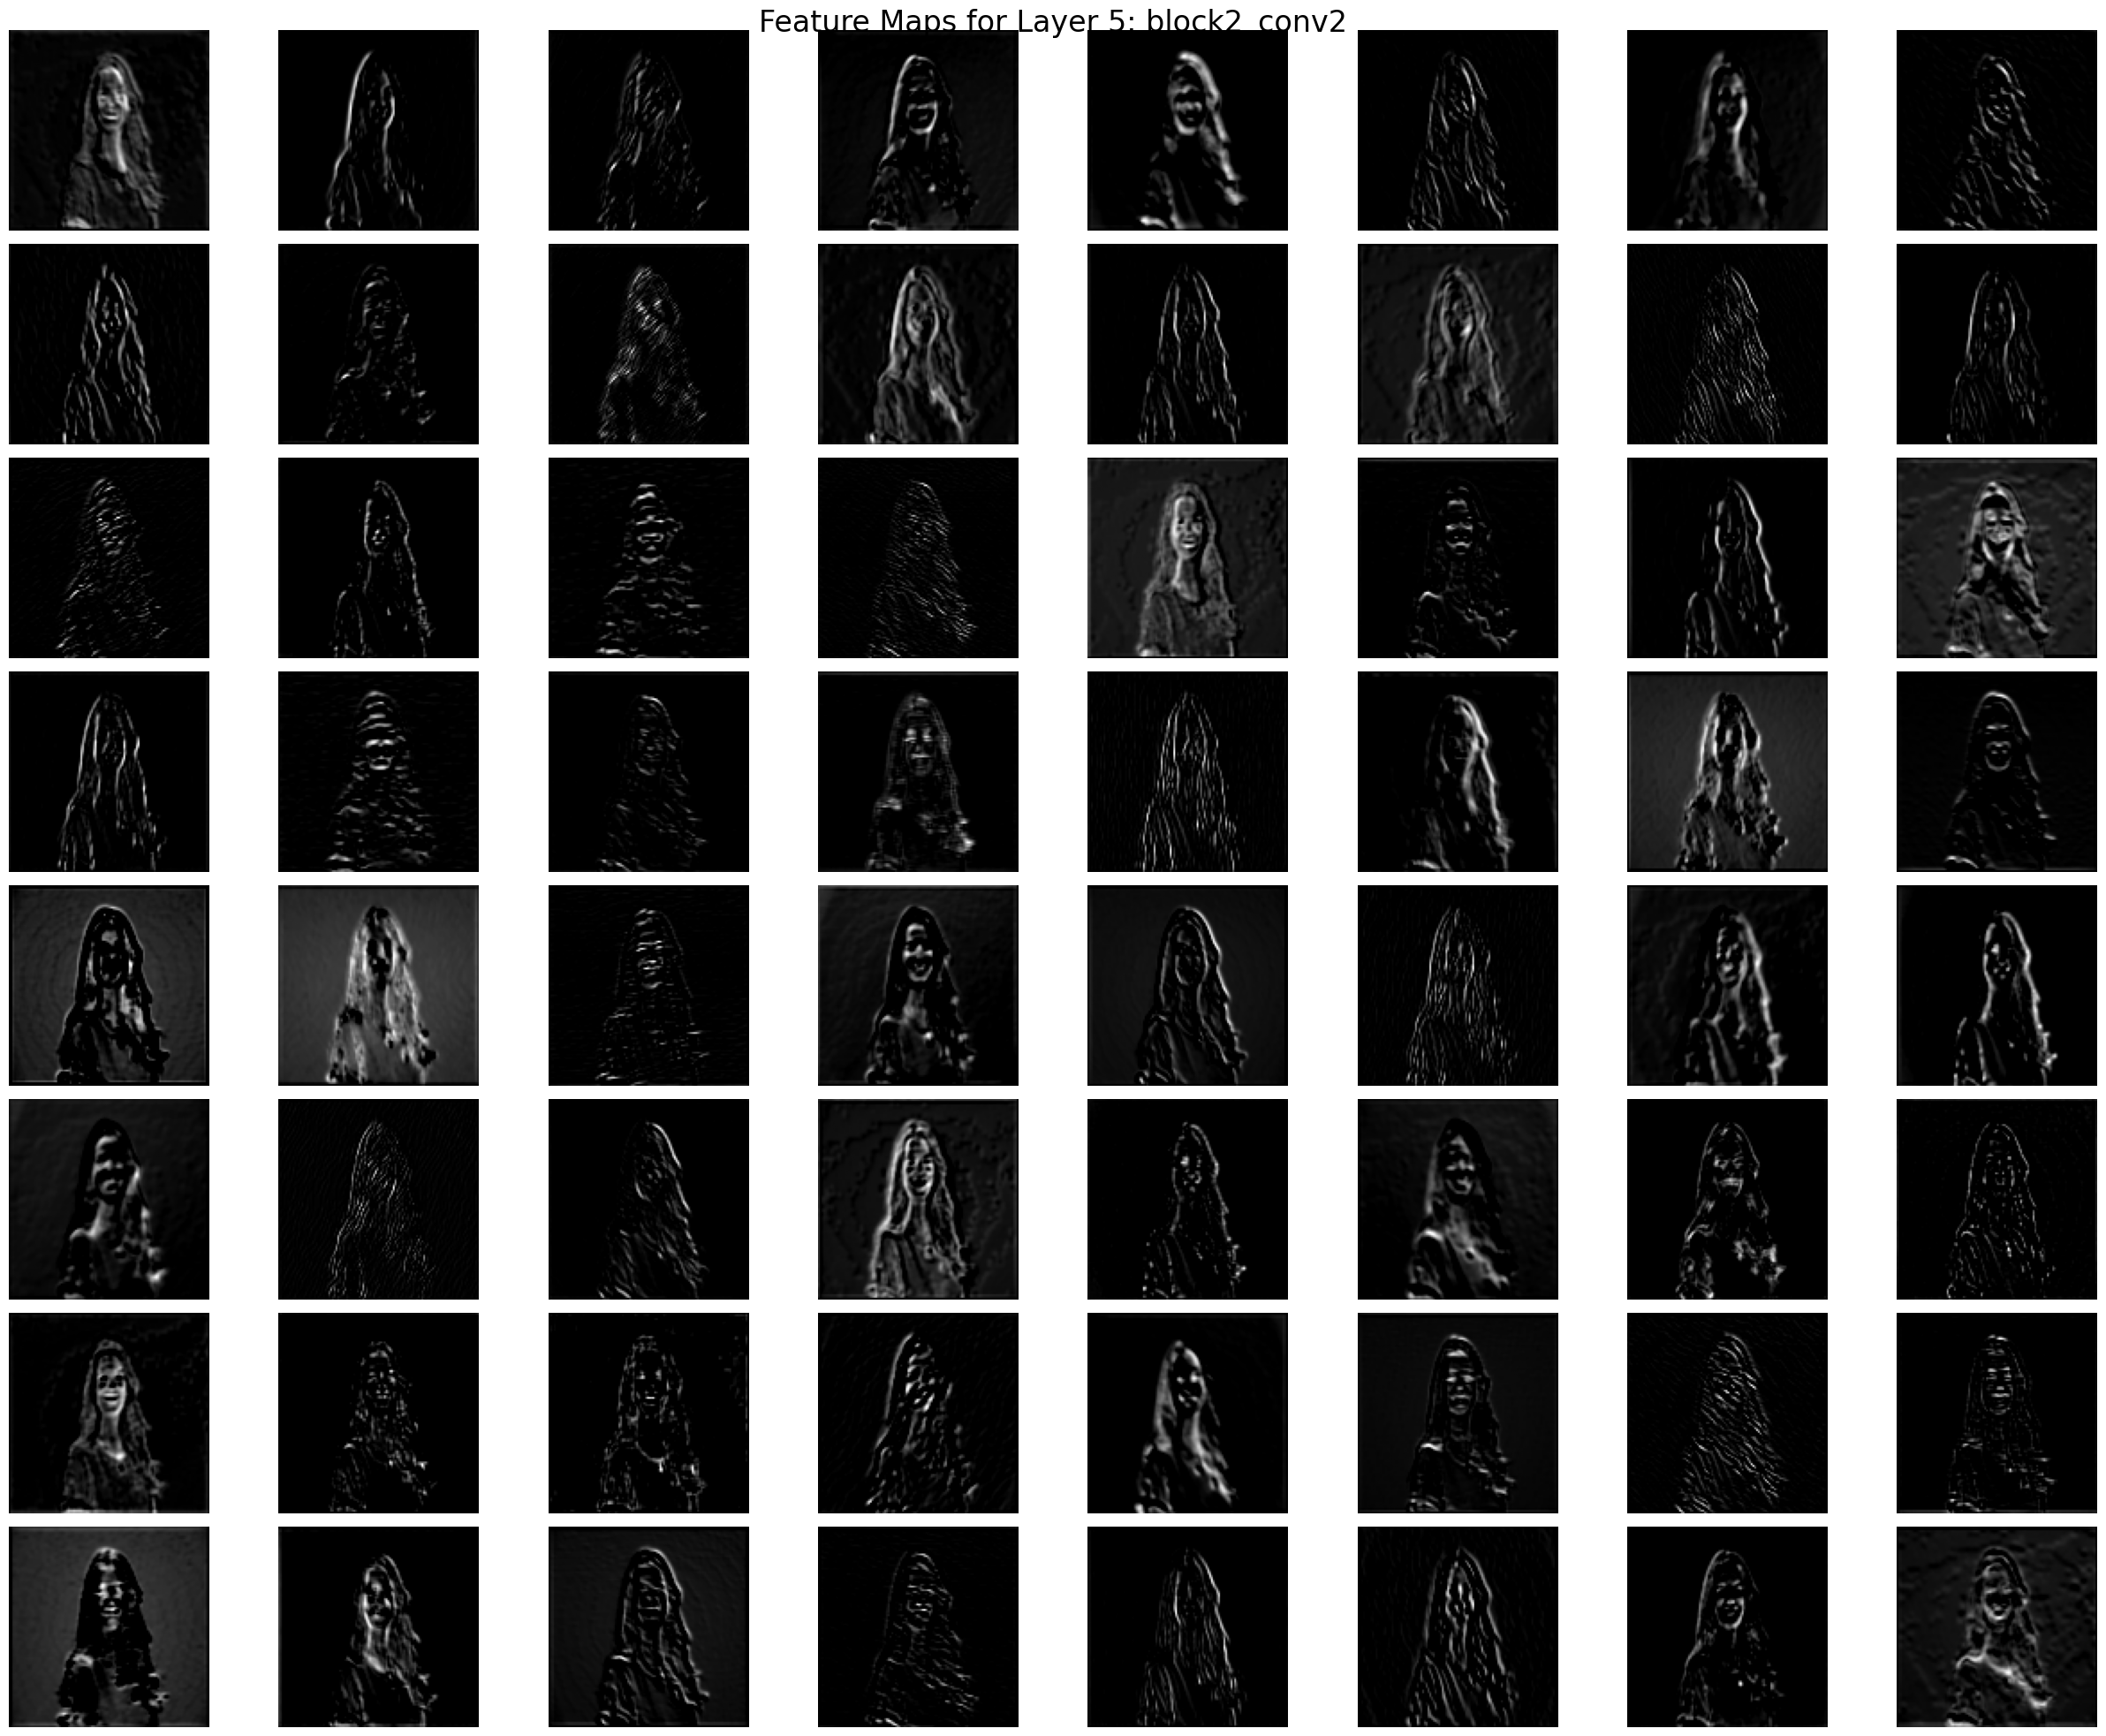

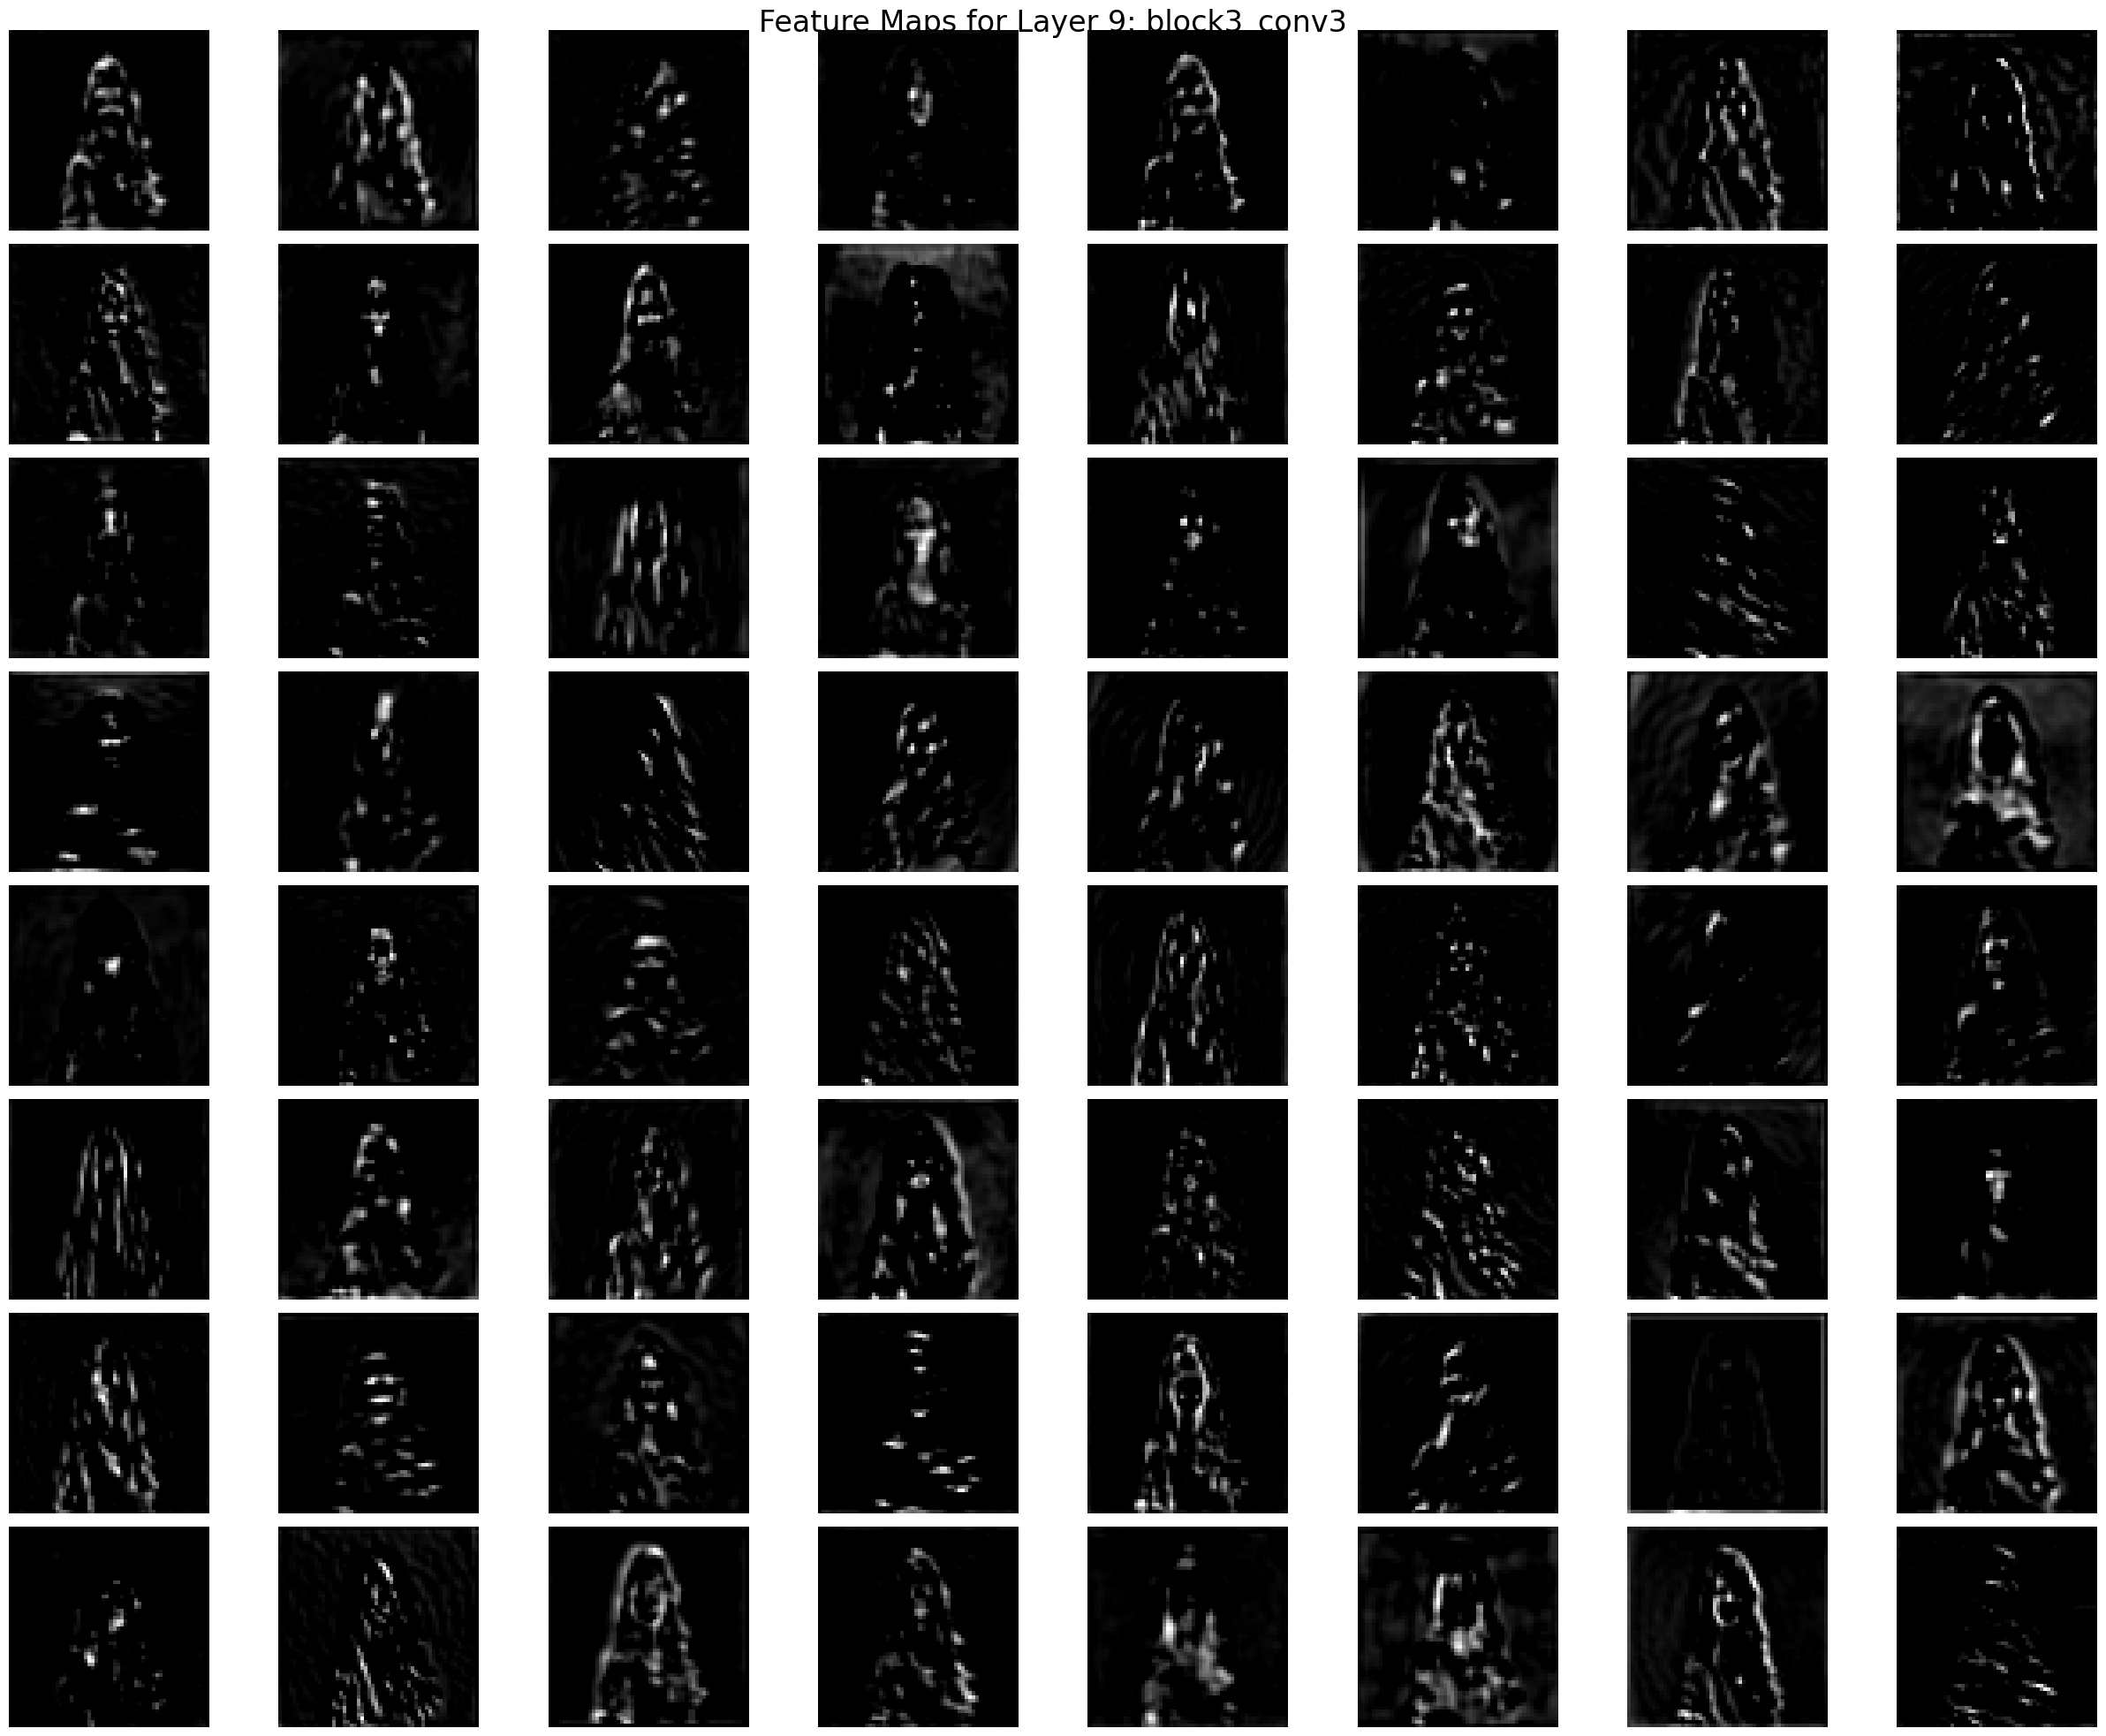

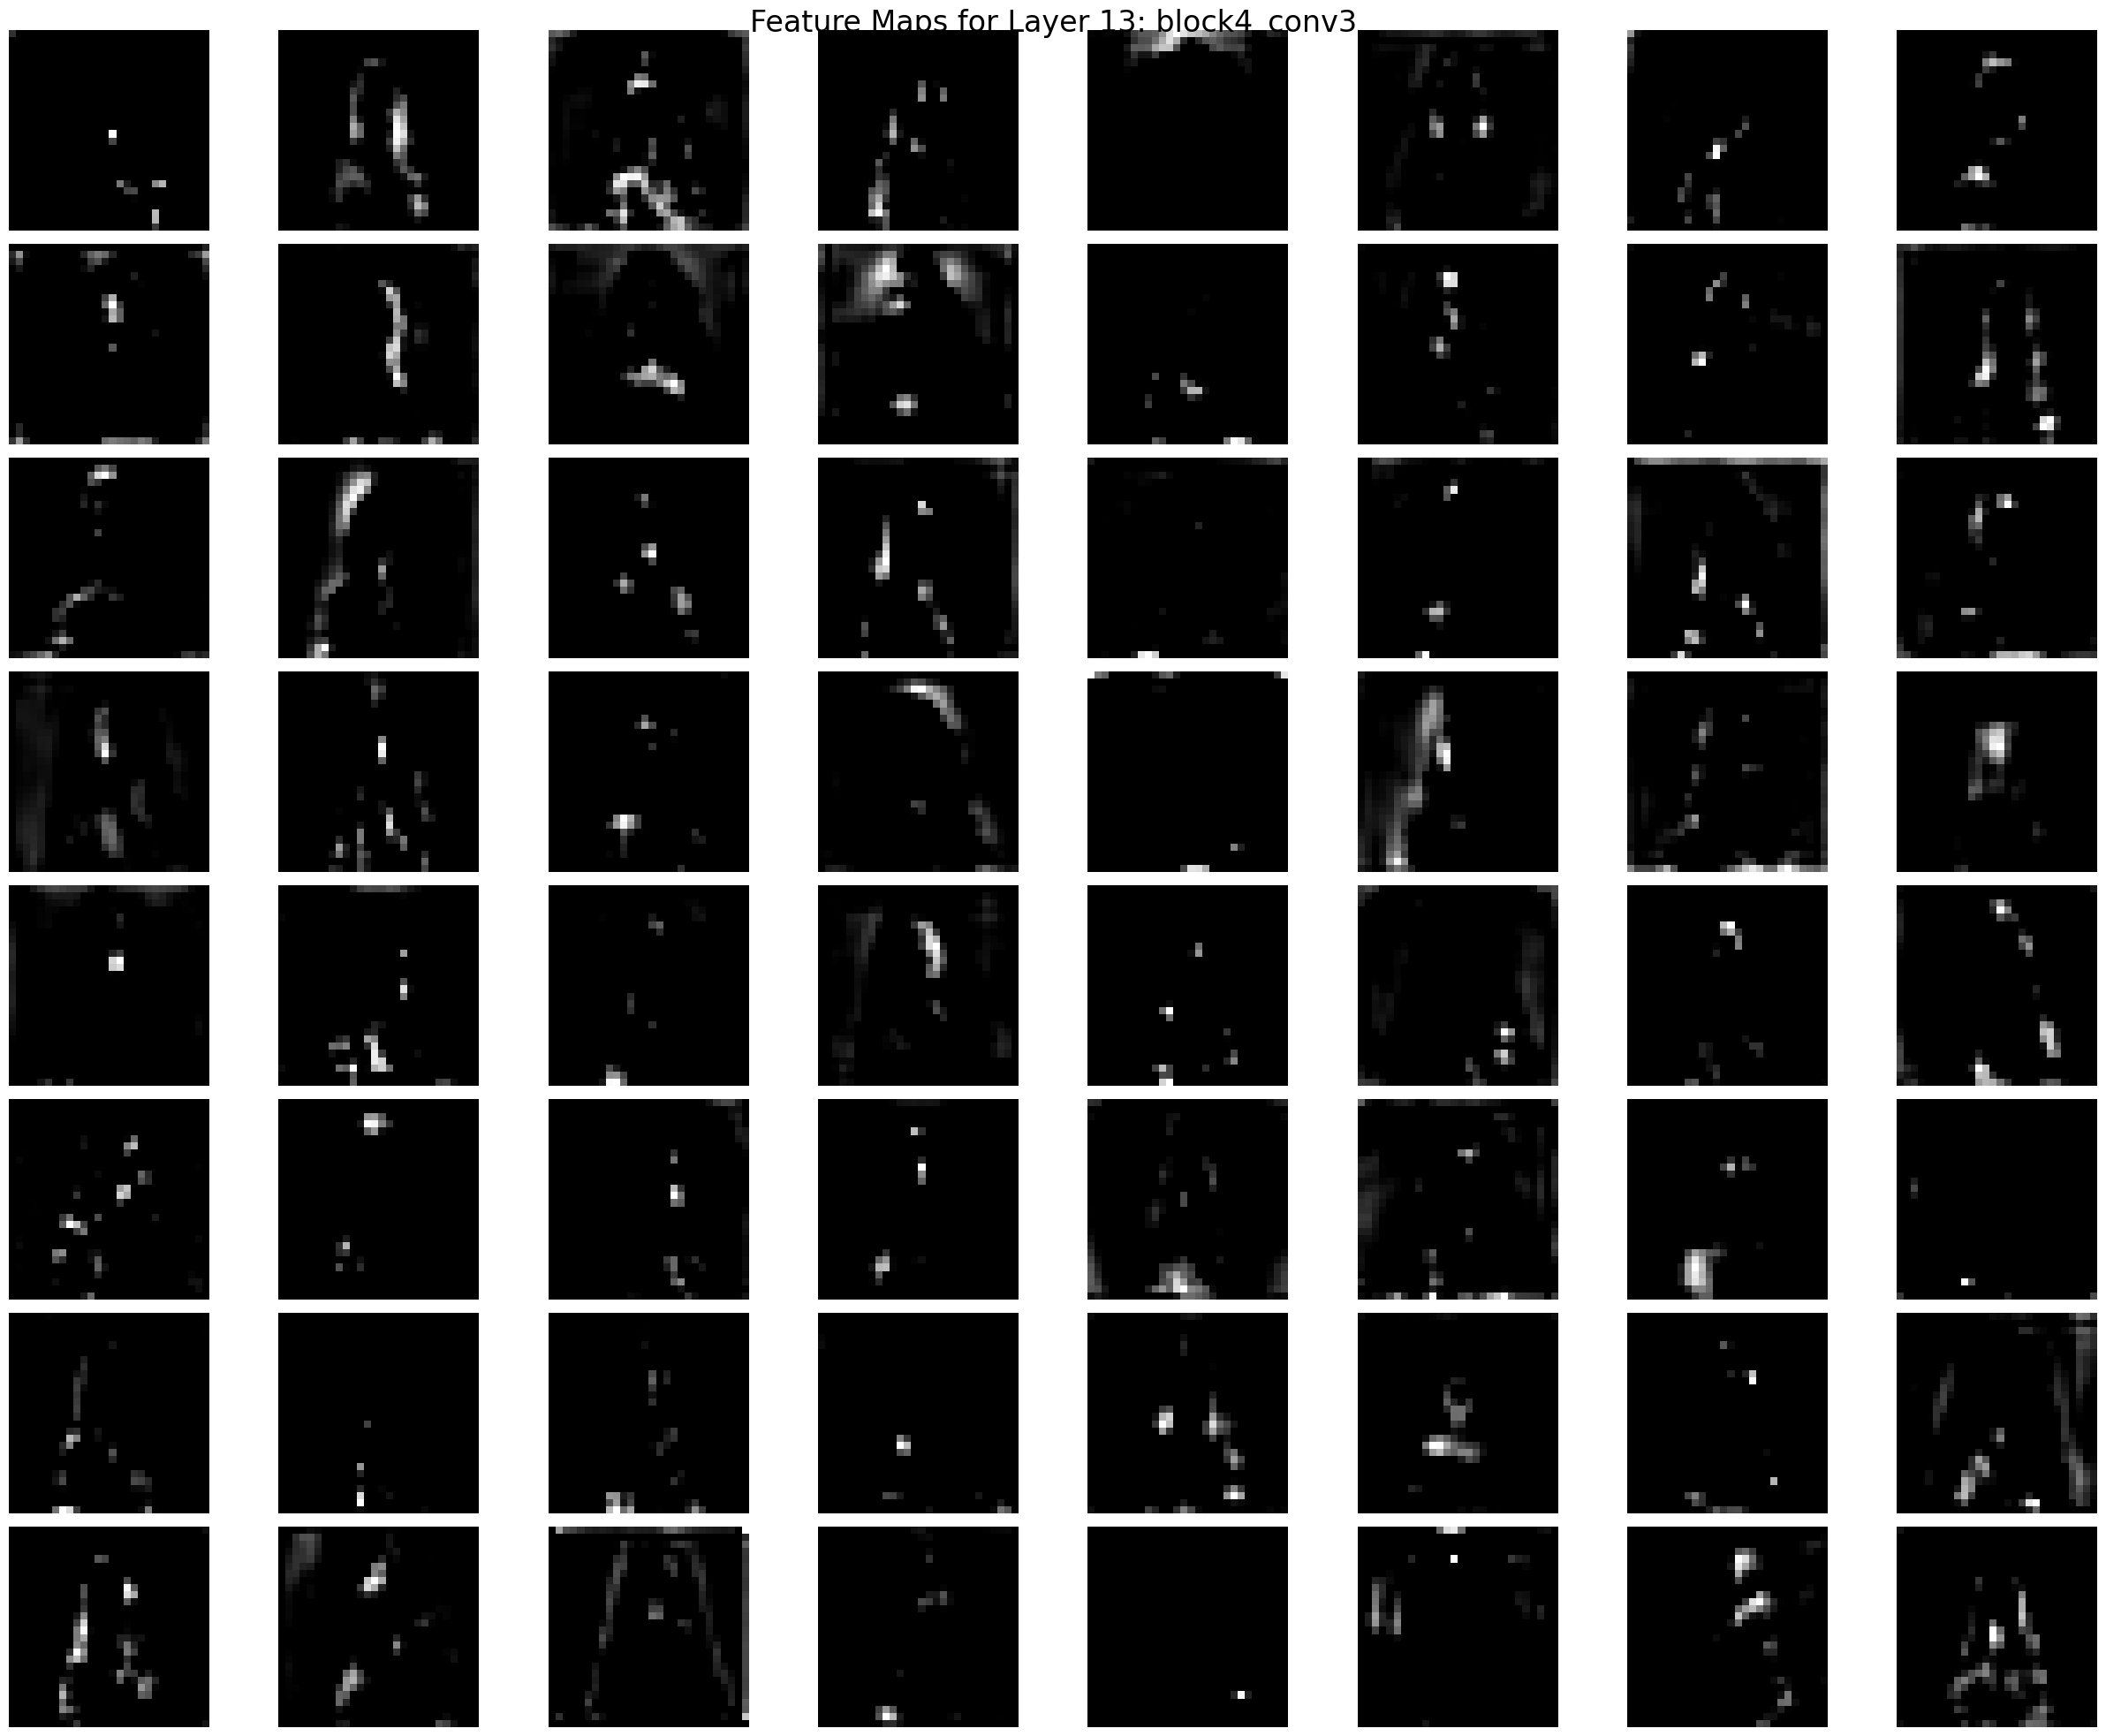

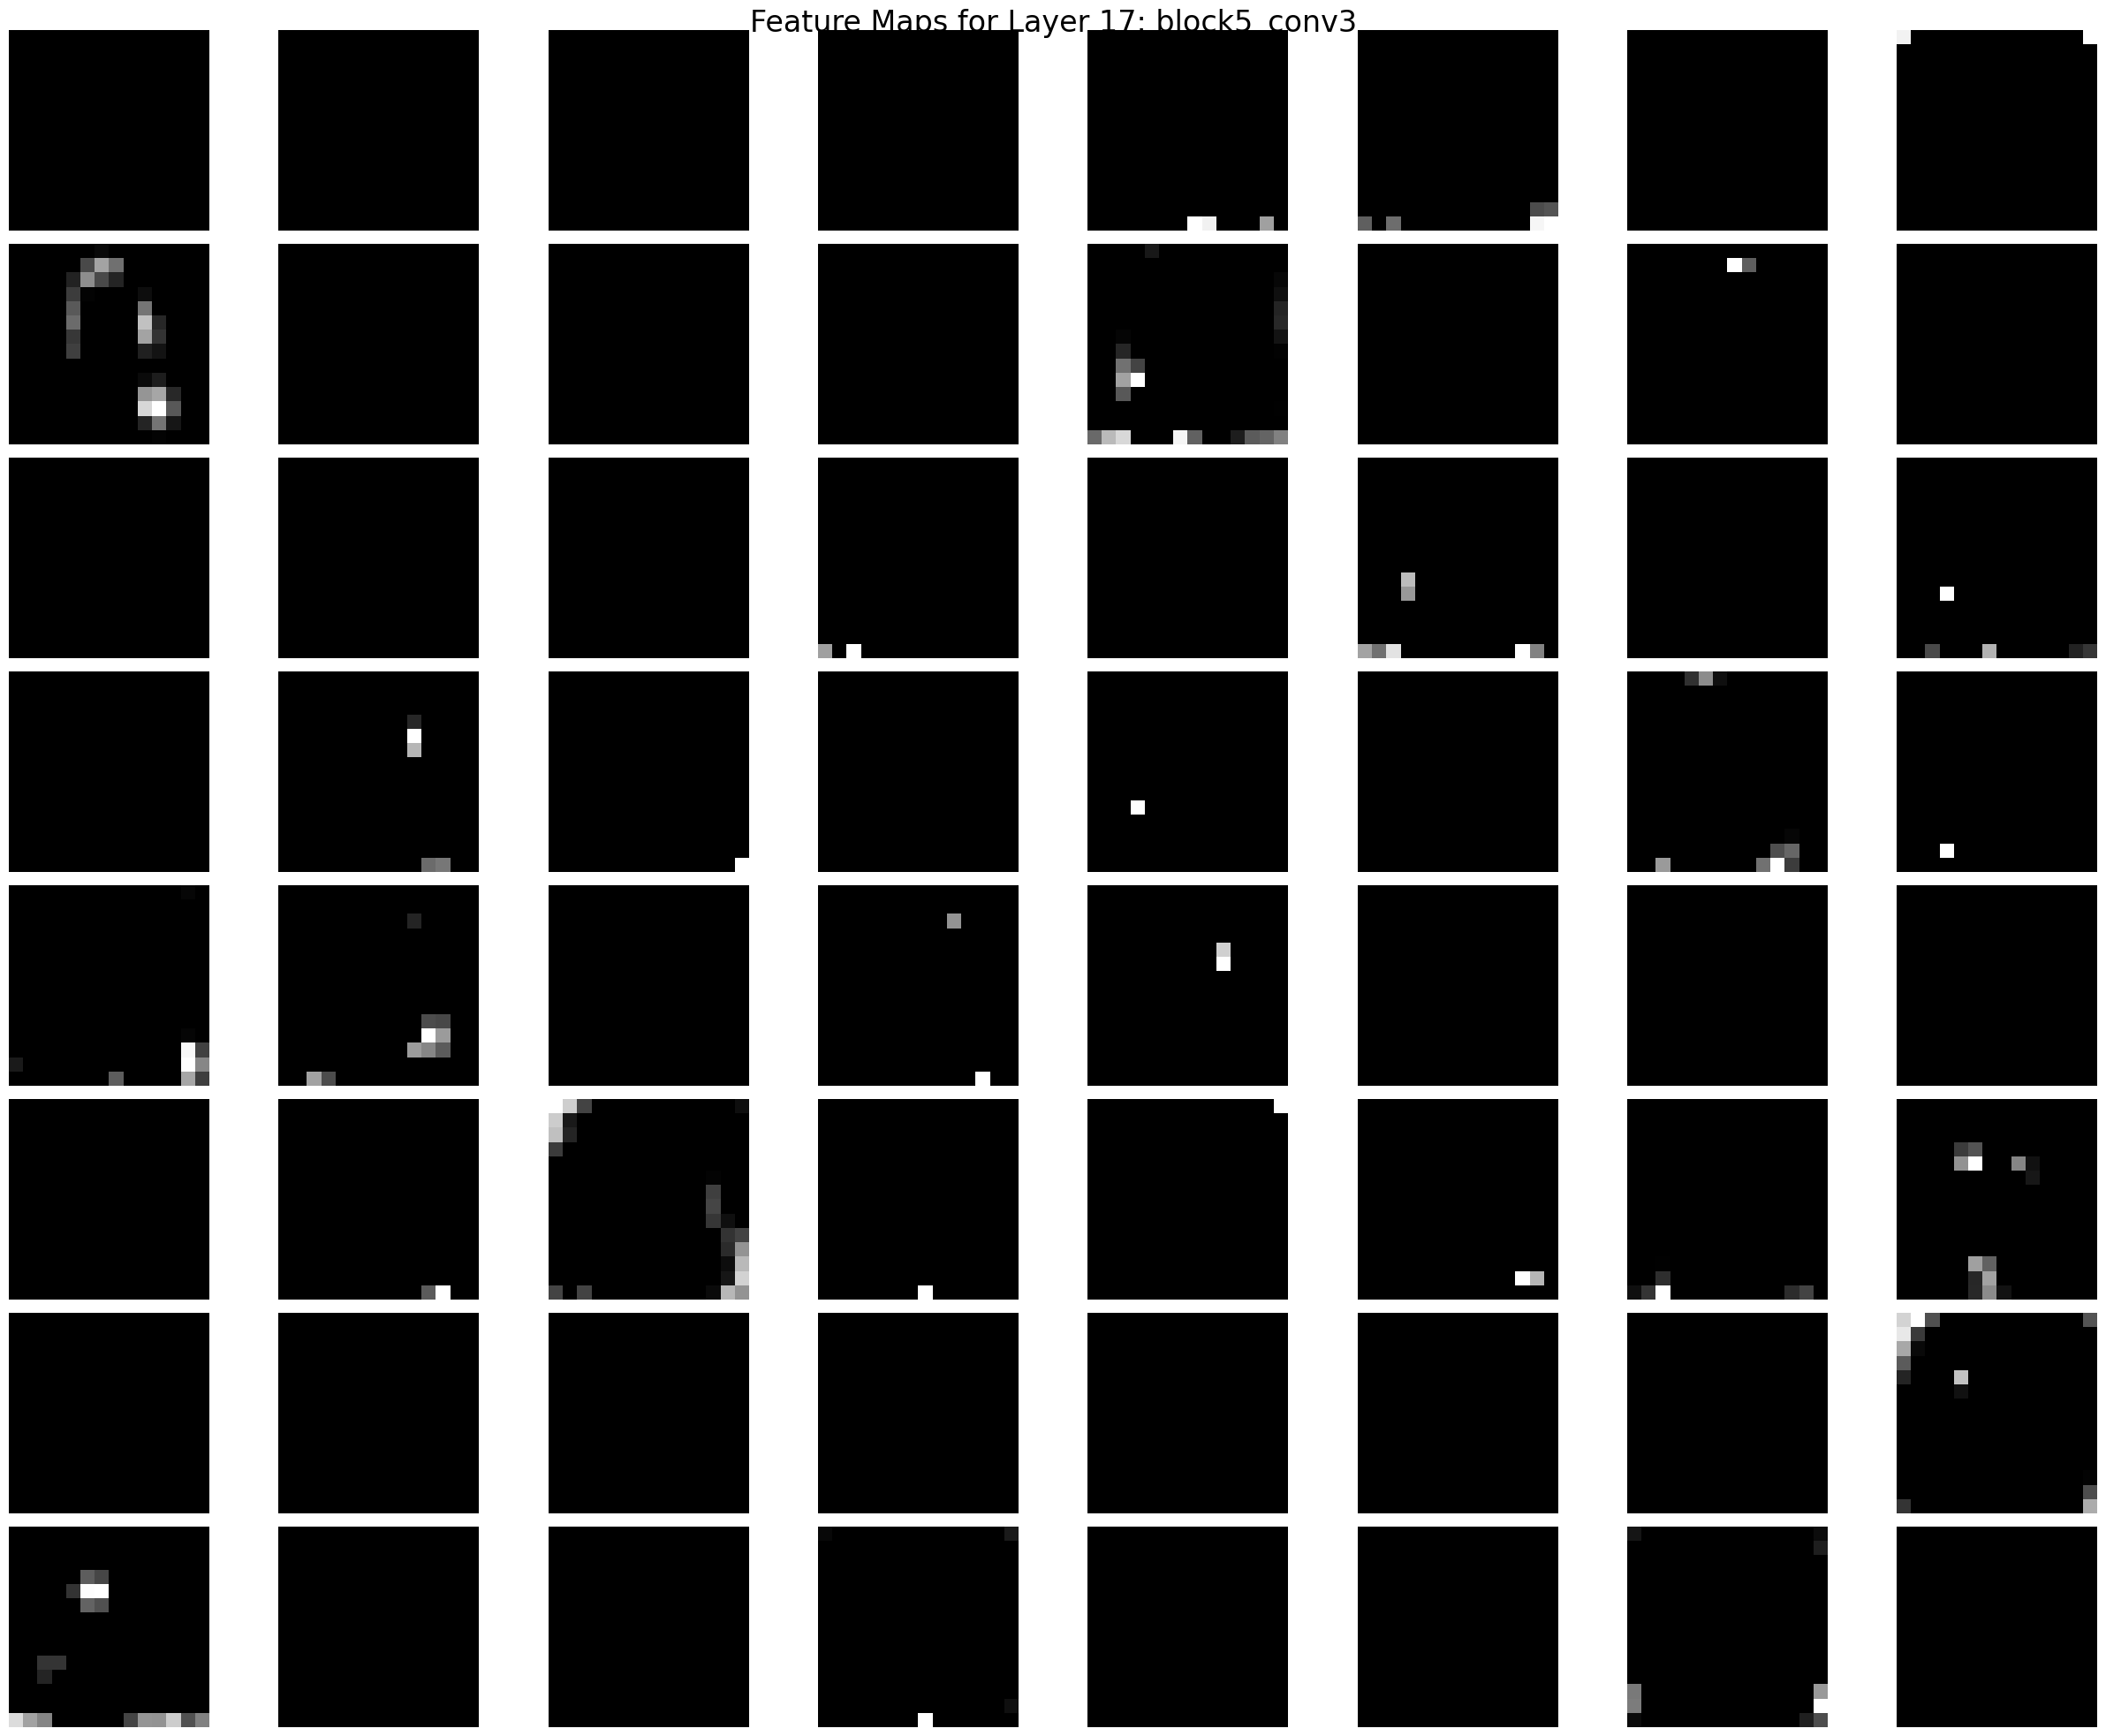

In [54]:
feature_maps = model3.predict(image)
for layer_idx, fmap in zip(layer_index, feature_maps):
  fig = pyplot.figure(figsize=(25,20))

  fig.suptitle(f"Feature Maps for Layer {layer_idx}: {model2.layers[layer_idx].name}", fontsize=24)


  num_channels = fmap.shape[3]
  display_limit = 64

  n_cols = 8
  n_rows = (min(num_channels, display_limit) + n_cols - 1) // n_cols


  for k in range(1, min(num_channels, display_limit) + 1):
    pyplot.subplot(n_rows, n_cols, k)
    pyplot.imshow(fmap[0,:,:,k-1], cmap='gray')
    pyplot.axis('off')

  pyplot.tight_layout()
  pyplot.show()

Finally, we visualize the feature maps from each of the selected intermediate layers. For each layer, we display up to 64 feature maps in an 8x8 grid. Observing these maps from earlier to deeper layers reveals the hierarchical nature of feature learning in CNNs: from simple edges and textures to more complex, abstract representations of objects or parts of objects.